# Practical 09 — Support Vector Machines and Hyperparameter Tuning

**Syllabus (Parul University):** *Implement Support Vector Machine and tune hyperparameters.*  
**Kernel:** `ml-lab-kernel`  
**Data:** Heart-disease style binary classification (`target` ∈ \{0,1\}).

### Outcomes

1. Max-margin geometry, primal/dual, slack $C$, kernels (linear, poly, RBF / $\gamma$).
2. NumPy $f(x)$ from **support vectors** and **dual coefficients**, matching `SVC.decision_function`.
3. Leakage-safe `StandardScaler` + `SVC` pipeline.
4. `GridSearchCV` on $C$, $\gamma$, kernel.
5. 2-D plots: decision surface, **margin gutters**, **circled SVs**; $(C,\gamma)$ CV heatmap.
6. Accuracy, confusion matrix, ROC-AUC.

---

## 1. Theory

### 1.1 Maximum margin (hard-margin, linearly separable)

Labels $y_i\in\{-1,+1\}$. A hyperplane $w^{\top}x+b=0$ has geometric margin $2/\|w\|$. Hard-margin SVM:

$$
\min_{w,b}\ \frac12\|w\|^2
\quad\text{s.t.}\quad
y_i(w^{\top}x_i+b)\ge 1\ \forall i.
$$

Support vectors lie on $y_i(w^{\top}x_i+b)=1$.

### 1.2 Lagrangian dual

With multipliers $\alpha_i\ge 0$,

$$
L=\frac12\|w\|^2-\sum_i\alpha_i\bigl[y_i(w^{\top}x_i+b)-1\bigr].
$$

Stationarity: $w=\sum_i\alpha_i y_i x_i$, $\sum_i\alpha_i y_i=0$. Dual (linear kernel):

$$
\max_{\alpha}\ \sum_i\alpha_i-\frac12\sum_{i,j}\alpha_i\alpha_j y_i y_j\,x_i^{\top}x_j
\quad\text{s.t.}\quad
\alpha_i\ge 0,\ \sum_i\alpha_i y_i=0.
$$

**Decision function**

$$
f(x)=\sum_{i\in\mathrm{SV}}\alpha_i y_i\,K(x_i,x)+b,
\qquad
\hat y=\mathrm{sign}(f(x)).
$$

sklearn stores `dual_coef_[0,i]=\alpha_i y_i` (binary) and `intercept_=[b]`.

### 1.3 Soft margin and $C$

Slack $\xi_i\ge 0$: $y_i(w^{\top}x_i+b)\ge 1-\xi_i$. Penalty

$$
\min_{w,b,\xi}\ \frac12\|w\|^2+C\sum_i\xi_i.
$$

**Large $C$:** few slacks, hard margin, risk of overfit. **Small $C$:** wider margin, more training errors allowed. Dual box constraint $0\le\alpha_i\le C$.

### 1.4 Kernels

$$
K_{\mathrm{lin}}(x,z)=x^{\top}z,
\quad
K_{\mathrm{poly}}(x,z)=(\gamma x^{\top}z+r)^{d},
\quad
K_{\mathrm{RBF}}(x,z)=\exp\bigl(-\gamma\|x-z\|^2\bigr).
$$

**$\gamma$** (RBF): large $\gamma$ $\Rightarrow$ narrow bumps around SVs (wiggly boundary); small $\gamma$ $\Rightarrow$ smooth, almost linear. sklearn `gamma='scale'` uses $1/(p\,\mathrm{Var}(X))$.

Always **scale** features: kernels and $\|x-z\|$ are not unit-invariant.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV` in the config cell.
3. No file: the lab loader falls back to a public URL / sklearn.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#0f766e") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    """1-click CSV upload on Colab."""
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — edit this cell to swap your CSV

```text
  DATA_PATH  ──►  TARGET_COLUMN  ──►  DROP_COLUMNS (IDs, names, …)
       │                 │
       └── path relative to this notebook
```

> **Why this matters:** the model does not guess the label column. A wrong `TARGET_COLUMN` is a wrong experiment.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to use your own CSV                ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = 'data/heart_disease.csv'
TARGET_COLUMN = 'target'
DROP_COLUMNS = []

# Colab-only (ignored locally):
COLAB_DRIVE_CSV = None  # e.g. "/content/drive/MyDrive/my_data.csv"
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

print("=" * 72)
print(" DATASET CONFIG")
print("=" * 72)
print(f"DATA_PATH       = {DATA_PATH}")
print(f"TARGET_COLUMN   = {TARGET_COLUMN}")
print(f"DROP_COLUMNS    = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local file exists: {_p.is_file()} ({_p.resolve() if _p.exists() else _p})")


 DATASET CONFIG
DATA_PATH       = data/heart_disease.csv
TARGET_COLUMN   = target
DROP_COLUMNS    = []
local file exists: True (D:\LiamCodes\parul-mtech-coding\ml-practical\09_SVM_Hyperparameter_Tuning\data\heart_disease.csv)


In [3]:
_rule("cell output")
from __future__ import annotations

import sys
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (14, 7),   # why: large on-screen figures for lab projection / PDF
    "figure.dpi": 140,           # why: high-DPI rendering (sharp saved outputs)
    "savefig.dpi": 300,          # why: print-quality exports
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 25)  # why: wide tables stay readable in the output pane
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 40)
print("Python", sys.version.split()[0])


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)



 cell output


Python 3.14.0


## 2. Dual-path load


In [4]:
_rule("cell output")
LOCAL = Path(DATA_PATH)
HEART_URL = (
    "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
)


def load_table() -> Tuple[pd.DataFrame, str]:
    if LOCAL.is_file():
        return pd.read_csv(LOCAL), "local"
    try:
        return pd.read_csv(HEART_URL), "url"
    except Exception as exc:
        print("URL failed:", type(exc).__name__, exc)
        bunch = load_breast_cancer(as_frame=True)
        frame = bunch.frame.copy()
        return frame, "sklearn_cancer"


df, origin = load_table()
print("origin =", origin, "shape =", df.shape)
print("columns", list(df.columns))
target_col = "target" if "target" in df.columns else df.columns[-1]
print("target_col =", target_col, df[target_col].value_counts().to_dict())
df.head(3)



 cell output
origin = local shape = (303, 14)
columns ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
target_col = target {1: 165, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


## 3. Split, scale, sklearn `SVC` pipeline


In [5]:
_rule("cell output")
y = (df[target_col].to_numpy() > 0).astype(int)
X = df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True)).to_numpy(dtype=np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print("train", X_train.shape, "test", X_test.shape, "pos rate", float(y_test.mean()))

pipe0 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)),
    ]
)
pipe0.fit(X_train, y_train)
print("baseline RBF test acc", round(accuracy_score(y_test, pipe0.predict(X_test)), 4))



 cell output
train (227, 13) test (76, 13) pos rate 0.5394736842105263
baseline RBF test acc 0.7632


## 4. NumPy dual decision function $f(x)$ from SVs

After scaling, sklearn’s binary `decision_function` is

$$
f(x)=\sum_{i=1}^{n_{\mathrm{sv}}} (\alpha_i y_i)\,K(x_i,x)+b
=\texttt{dual\_coef}\cdot K(\mathrm{SV},x)+b.
$$


In [6]:
_rule("cell output")
def rbf_kernel(X: np.ndarray, Y: np.ndarray, gamma: float) -> np.ndarray:
    X2 = np.sum(X * X, axis=1, keepdims=True)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T
    d2 = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)
    return np.exp(-gamma * d2)


def poly_kernel(X: np.ndarray, Y: np.ndarray, gamma: float, degree: int, coef0: float) -> np.ndarray:
    return (gamma * (X @ Y.T) + coef0) ** degree


def linear_kernel(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    return X @ Y.T


def svm_decision_numpy(Xq: np.ndarray, svc: SVC, gamma_resolved: float) -> np.ndarray:
    sv = svc.support_vectors_
    dual = svc.dual_coef_  # (1, n_sv)
    b = float(svc.intercept_[0])
    if svc.kernel == "linear":
        K = linear_kernel(Xq, sv)
    elif svc.kernel == "rbf":
        K = rbf_kernel(Xq, sv, gamma_resolved)
    elif svc.kernel == "poly":
        K = poly_kernel(Xq, sv, gamma_resolved, int(svc.degree), float(svc.coef0))
    else:
        raise ValueError(svc.kernel)
    return (dual @ K.T).ravel() + b


# Resolve gamma='scale' as sklearn: 1 / (n_features * X.var())
scaler = pipe0.named_steps["scaler"]
Xtr_s = scaler.transform(X_train)
Xte_s = scaler.transform(X_test)
svc_r = pipe0.named_steps["svc"]
gamma_r = svc_r._gamma if hasattr(svc_r, "_gamma") else 1.0 / (Xtr_s.shape[1] * Xtr_s.var())
f_np = svm_decision_numpy(Xte_s, svc_r, float(gamma_r))
f_sk = svc_r.decision_function(Xte_s)
print("max |f_numpy - f_sklearn| =", float(np.max(np.abs(f_np - f_sk))))
print("n_support =", svc_r.n_support_, "total SV", svc_r.support_vectors_.shape[0])
assert np.allclose(f_np, f_sk, atol=1e-6)
print("NumPy dual f(x) matches sklearn.")



 cell output
max |f_numpy - f_sklearn| = 9.2148511043888e-15
n_support = [67 65] total SV 132
NumPy dual f(x) matches sklearn.


## 5. `GridSearchCV` over kernel, $C$, $\gamma$


In [7]:
_rule("cell output")
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(random_state=SEED)),
    ]
)
param_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10, 50]},
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 50],
        "svc__gamma": [0.001, 0.01, 0.1, 1.0],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10],
        "svc__degree": [2, 3],
        "svc__gamma": ["scale"],
    },
]
search = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=1, refit=True)
search.fit(X_train, y_train)
print("best params", search.best_params_, "cv ROC-AUC", round(search.best_score_, 4))
best = search.best_estimator_
y_pred = best.predict(X_test)
y_score = best.decision_function(X_test)
print("test acc", round(accuracy_score(y_test, y_pred), 4), "test ROC-AUC", round(roc_auc_score(y_test, y_score), 4))
print(classification_report(y_test, y_pred, target_names=["no disease", "disease"]))



 cell output


best params {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'} cv ROC-AUC 0.9214
test acc 0.7763 test ROC-AUC 0.8425
              precision    recall  f1-score   support

  no disease       0.80      0.69      0.74        35
     disease       0.76      0.85      0.80        41

    accuracy                           0.78        76
   macro avg       0.78      0.77      0.77        76
weighted avg       0.78      0.78      0.77        76



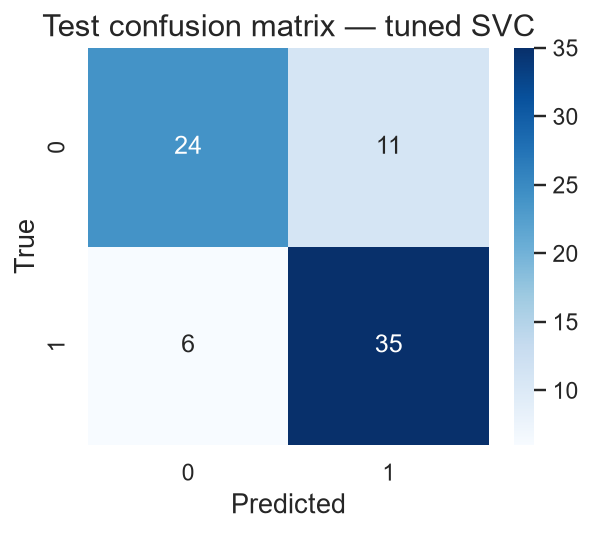

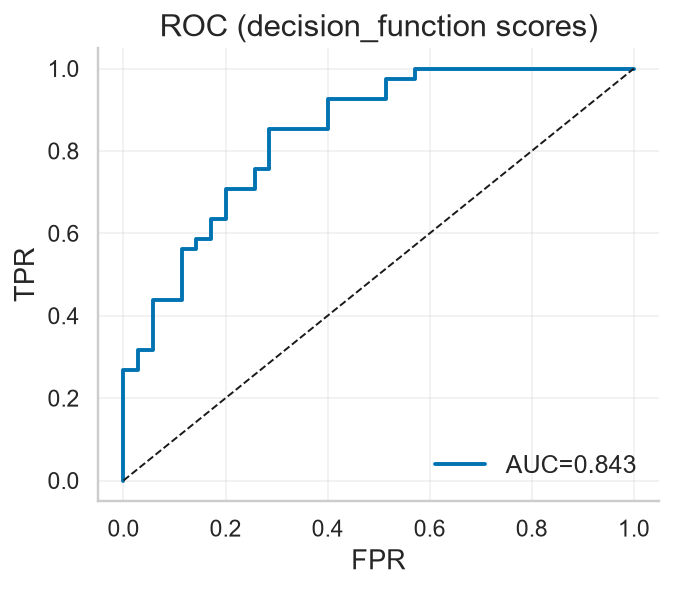

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4.0))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0", "1"], yticklabels=["0", "1"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test confusion matrix — tuned SVC")
fig.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_score)
fig, ax = plt.subplots(figsize=(5.0, 4.4))
ax.plot(fpr, tpr, lw=2, label=f"AUC={roc_auc_score(y_test, y_score):.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC (decision_function scores)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 6. RBF validation heatmap $(C,\gamma)$



 cell output


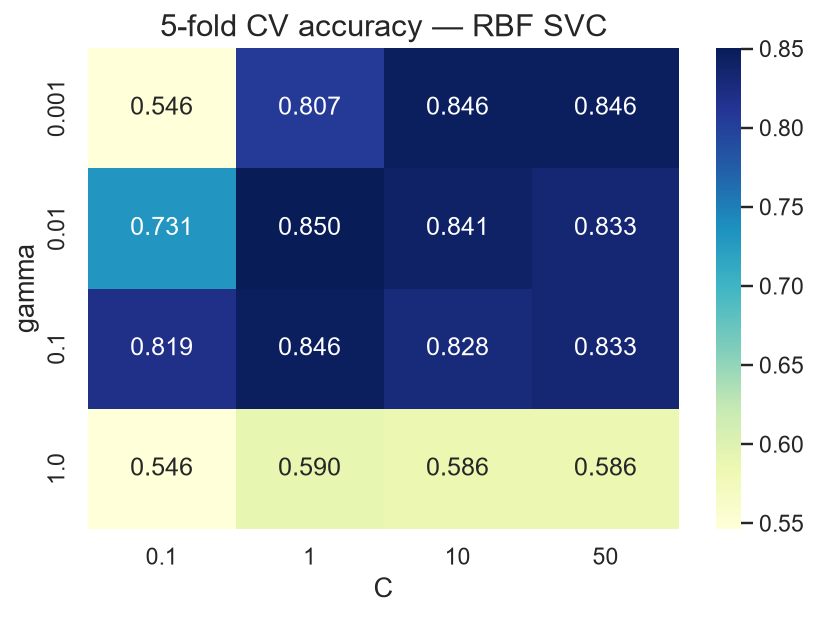

RBF heatmap best {'svc__C': 1, 'svc__gamma': 0.01} 0.8504


In [9]:
_rule("cell output")
Cs = [0.1, 1, 10, 50]
gammas = [0.001, 0.01, 0.1, 1.0]
rbf_search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", random_state=SEED))]),
    {"svc__C": Cs, "svc__gamma": gammas},
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)
rbf_search.fit(X_train, y_train)
res = pd.DataFrame(rbf_search.cv_results_)
heat = np.zeros((len(gammas), len(Cs)))
for i, g in enumerate(gammas):
    for j, c in enumerate(Cs):
        m = (res["param_svc__C"] == c) & (res["param_svc__gamma"] == g)
        heat[i, j] = float(res.loc[m, "mean_test_score"].iloc[0])

fig, ax = plt.subplots(figsize=(6.2, 4.6))
sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=Cs,
    yticklabels=gammas,
    ax=ax,
    vmin=heat.min(),
    vmax=heat.max(),
)
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title("5-fold CV accuracy — RBF SVC")
fig.tight_layout()
plt.show()
print("RBF heatmap best", rbf_search.best_params_, round(rbf_search.best_score_, 4))


## 7. 2-D decision regions, margin gutters, circled support vectors

Full $p$-D SVs cannot be drawn. We PCA-project **scaled train data** to 2-D, fit **Linear / Poly / RBF** SVC **in that plane**, and plot $\{f=0\}$ plus gutters $\{f=\pm 1\}$. Support vectors are **circled**. This illustrates kernel geometry; reported accuracy remains the **full-feature** tuned pipeline.


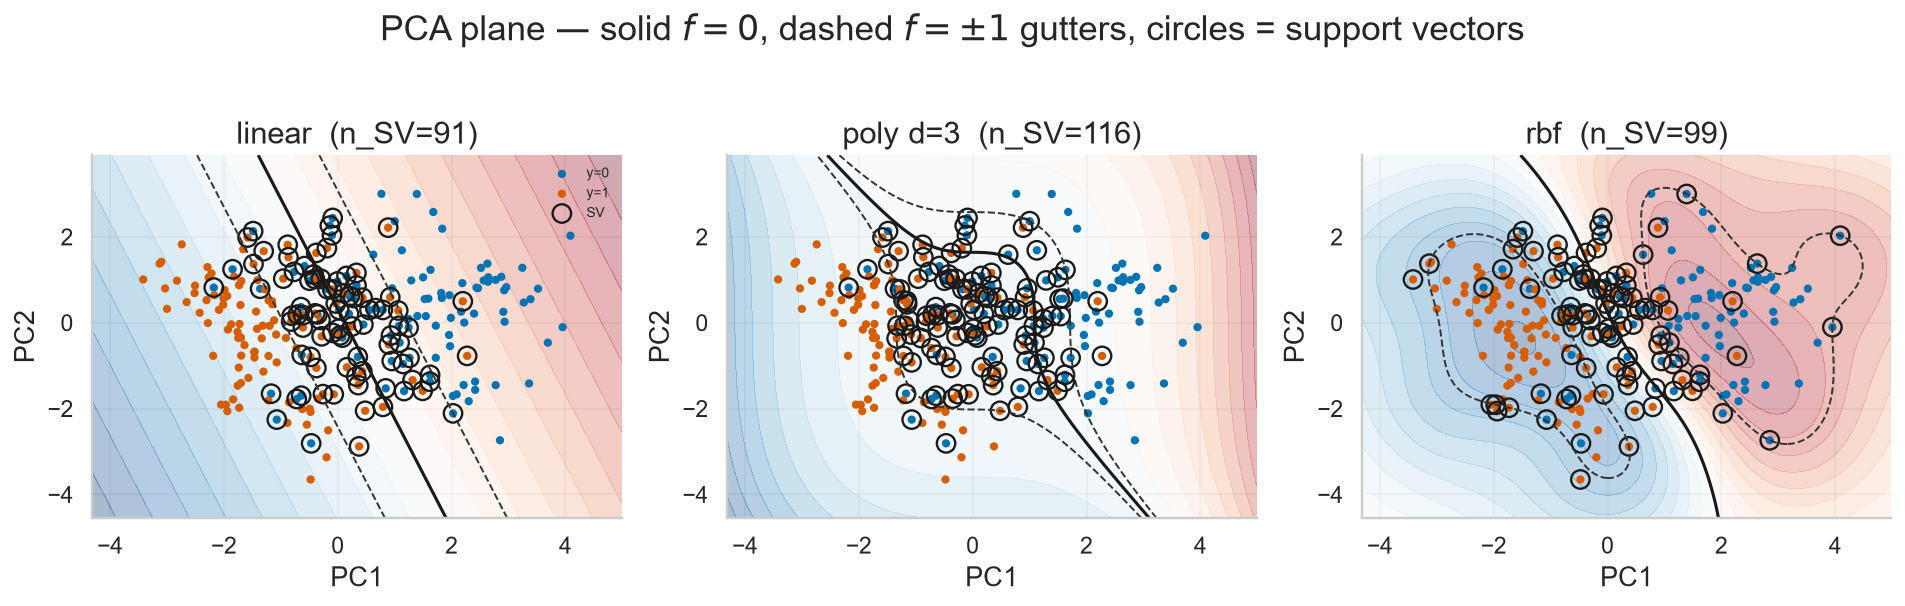

In [10]:
pca = PCA(n_components=2, random_state=SEED)
Ztr = pca.fit_transform(Xtr_s)
pad = 0.9
g1 = np.linspace(Ztr[:, 0].min() - pad, Ztr[:, 0].max() + pad, 280)
g2 = np.linspace(Ztr[:, 1].min() - pad, Ztr[:, 1].max() + pad, 280)
xx, yy = np.meshgrid(g1, g2)
grid = np.column_stack([xx.ravel(), yy.ravel()])

specs = [
    ("linear", dict(kernel="linear", C=1.0)),
    ("poly d=3", dict(kernel="poly", degree=3, C=1.0, gamma="scale")),
    ("rbf", dict(kernel="rbf", C=1.0, gamma="scale")),
]

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2))
for ax, (title, kw) in zip(axes, specs):
    clf2 = SVC(**kw)
    clf2.fit(Ztr, y_train)
    zz = clf2.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=20, cmap="RdBu", alpha=0.35)
    ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors=["0.2", "k", "0.2"], linestyles=["--", "-", "--"], linewidths=[1.0, 1.6, 1.0])
    ax.scatter(Ztr[y_train == 0, 0], Ztr[y_train == 0, 1], c="C0", s=18, edgecolor="none", label="y=0")
    ax.scatter(Ztr[y_train == 1, 0], Ztr[y_train == 1, 1], c="C3", s=18, edgecolor="none", label="y=1")
    sv = clf2.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=90, facecolors="none", edgecolors="k", linewidths=1.2, label="SV")
    ax.set_title(title + f"  (n_SV={sv.shape[0]})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
axes[0].legend(frameon=False, fontsize=7, loc="best")
fig.suptitle(r"PCA plane — solid $f=0$, dashed $f=\pm 1$ gutters, circles = support vectors", y=1.03)
fig.tight_layout()
plt.show()


## 8. Viva-voce

**Q1. What is maximised by a hard-margin SVM?**  
**A.** Geometric margin $2/\|w\|$ subject to correct classification with functional margin $\ge 1$.

**Q2. Role of support vectors?**  
**A.** Only points with $\alpha_i>0$ (on or inside the margin / slack) determine $w$ and $f$. Removing far-correct points does not change the solution.

**Q3. What does $C$ trade off?**  
**A.** Training slack vs margin width. Large $C$ $\approx$ hard margin.

**Q4. Dual vs primal?**  
**A.** Dual depends on $K(x_i,x_j)$ and $n$ multipliers — the kernel trick. Primal is $w\in\mathbb{R}^{p}$ (linear SVM can use primal `LinearSVC`).

**Q5. Why $\gamma$ in RBF?**  
**A.** $\gamma$ sets the length-scale of $\exp(-\gamma\|x-z\|^2)$. Too large $\Rightarrow$ overfit islands around SVs.

**Q6. Why scale?**  
**A.** Features in different units distort $\|x-z\|$ and inner products.

**Q7. Polynomial kernel parameters?**  
**A.** Degree $d$, $\gamma$, and coef0 $r$ in $(\gamma x^{\top}z+r)^d$.

**Q8. How did NumPy $f(x)$ match sklearn?**  
**A.** Same SVs, `dual_coef_`, resolved $\gamma$, and the same $K$.

**Q9. Why ROC from `decision_function` not `predict_proba`?**  
**A.** Platt scaling (`probability=True`) is extra and not required for AUC of the ranking induced by $f(x)$.

**Q10. Nested vs this GridSearch?**  
**A.** We tune on train CV then evaluate test once. Nested CV would be less optimistic; this lab is a single outer split.

**Q11. Linear kernel in 2-D PCA vs original $p$-D linear SVM?**  
**A.** Different models. PCA plot is pedagogical.

**Q12. What if classes overlap completely?**  
**A.** Soft-margin still returns a hyperplane; training error need not be zero. Check $C$ and class weight.


## 9. Summary

- Parul outcome: **implement SVM** and **tune hyperparameters** — here $C$, $\gamma$, kernel on a heart-disease table.
- Dual $f(x)$ from SVs is the operational formula; NumPy reproduces sklearn.
- **Scale inside the pipeline**; search with **GridSearchCV**; report **test ROC-AUC**, not only CV.
- Margin plots show why RBF can bend around SVs while linear stays a strip.

Do not edit `extra/`.

---
*End of Practical 09. Record load origin, best params, n_SV, NumPy $f$ max-abs error, test AUC. Kernel: `ml-lab-kernel`.*
